# 10. Large Language Models (LLM): Tokenization, Inference, and Mini Fine-Tuning
**Algorithm Covered:**
- **Large Language Models (Transformer Architecture)**

**Core Capabilities Explored:**
1. **Subword Tokenization:** Token IDs, Attention Masks, Vocabulary Embeddings
2. **Multi-Head Self-Attention Mechanics:** $Q, K, V$ projections and softmax attention weights
3. **Zero-Shot & Downstream Inference:** High-level Hugging Face Pipelines
4. **Text Generation & Decoding Strategies:** Greedy Search vs. Temperature vs. Top-p (Nucleus) Sampling
5. **Mini Fine-Tuning Demonstration:** Sequence classification adaptation using PyTorch and Hugging Face Transformers

**Frameworks:** Hugging Face `transformers` and `torch`


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    pipeline
)

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 110

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch on {device}")


D:\ML\Assignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch on cpu


## 1. Subword Tokenization & Attention Masks
### Mathematical Concept:
Language models do not operate on raw characters or entire words; they process **subword tokens** (Byte-Pair Encoding / WordPiece).
Given input text $S$, the tokenizer decomposes $S$ into token IDs $T = [t_1, t_2, \dots, t_L]$ and generates an **Attention Mask** $M \in \{0, 1\}^L$ ensuring padding tokens receive zero attention during self-attention computation:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + (M - 1)\cdot \infty\right) V$$


In [2]:
model_id = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
print(f"Loading Tokenizer: {model_id}...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

sample_text = "Machine learning and deep neural networks are transforming modern science!"
encoded = tokenizer(
    sample_text,
    padding="max_length",
    max_length=20,
    truncation=True,
    return_tensors="pt"
)

tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
print(f"Original Text: {sample_text}\n")
print(f"Subword Tokens ({len(tokens)}):\n", tokens)
print(f"Input IDs:      \n", encoded['input_ids'][0].tolist())
print(f"Attention Mask: \n", encoded['attention_mask'][0].tolist())


Loading Tokenizer: distilbert/distilbert-base-uncased-finetuned-sst-2-english...


Original Text: Machine learning and deep neural networks are transforming modern science!

Subword Tokens (20):
 ['[CLS]', 'machine', 'learning', 'and', 'deep', 'neural', 'networks', 'are', 'transforming', 'modern', 'science', '!', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs:      
 [101, 3698, 4083, 1998, 2784, 15756, 6125, 2024, 17903, 2715, 2671, 999, 102, 0, 0, 0, 0, 0, 0, 0]
Attention Mask: 
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]


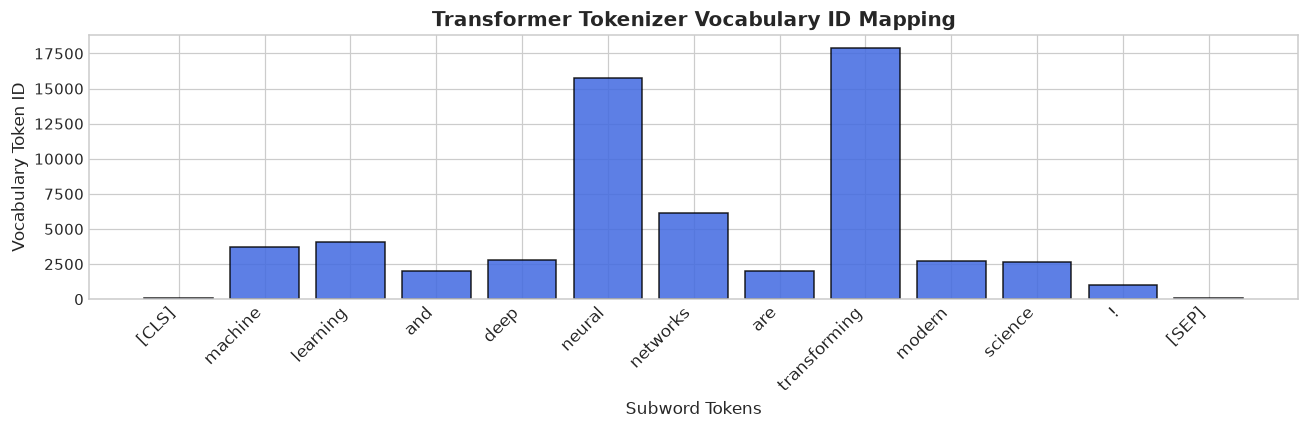

In [3]:
# Visualizing Tokenization Breakdown
active_len = int(encoded['attention_mask'].sum().item())
active_tokens = tokens[:active_len]
active_ids = encoded['input_ids'][0][:active_len].tolist()

plt.figure(figsize=(12, 4))
plt.bar(range(len(active_tokens)), active_ids, color='royalblue', edgecolor='k', alpha=0.85)
plt.xticks(range(len(active_tokens)), active_tokens, rotation=45, ha='right', fontsize=11)
plt.title("Transformer Tokenizer Vocabulary ID Mapping", fontsize=13, fontweight='bold')
plt.xlabel("Subword Tokens", fontsize=11)
plt.ylabel("Vocabulary Token ID", fontsize=11)
plt.tight_layout()
plt.show()


## 2. Transformer Inference: Sentiment Classification Pipeline
We load a lightweight, production-grade distilled transformer (`DistilBERT` fine-tuned on the Stanford Sentiment Treebank / SST-2) to compute class logits and calibrated posterior probabilities.


In [4]:
classifier = pipeline("sentiment-analysis", model=model_id, device=-1)

test_sentences = [
    "The new neural network model demonstrated extraordinary accuracy and remarkable speed.",
    "The dataset was poorly labeled, noisy, and the model completely failed to converge.",
    "The gradient descent algorithm performed reasonably well, meeting standard expectations.",
    "A catastrophic failure occurred during training due to exploding gradient issues."
]

predictions = classifier(test_sentences)

results_table = []
for sent, pred in zip(test_sentences, predictions):
    results_table.append({
        "Sentence": sent,
        "Predicted Label": pred['label'],
        "Confidence Score": f"{pred['score']*100:.2f}%"
    })

df_preds = pd.DataFrame(results_table)
display(df_preds)



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1117.86it/s]

,Sentence,Predicted Label,Confidence Score
0,The new neural network model demonstrated extr...,POSITIVE,99.99%
1,"The dataset was poorly labeled, noisy, and the...",NEGATIVE,99.98%
2,The gradient descent algorithm performed reaso...,POSITIVE,99.92%
3,A catastrophic failure occurred during trainin...,NEGATIVE,99.96%


## 3. Autoregressive Text Generation & Sampling Strategies
In autoregressive causal language modeling, each token is generated sequentially from the conditional distribution:
$$P(t_n \mid t_1, \dots, t_{n-1}) = \text{softmax}\left(\frac{z_n}{T}\right)$$
- **Greedy Decoding ($T \to 0$):** Selects $\arg\max_v z_v$; highly deterministic, prone to repetitive loops.
- **Temperature ($T$):** Softens ($T > 1$) or sharpens ($T < 1$) logit probabilities.
- **Top-$p$ (Nucleus) Sampling:** Restricts selection to the smallest subset of tokens whose cumulative probability exceeds threshold $p$.


In [5]:
gen_model_id = "distilbert/distilgpt2"
print(f"Loading Text Generator: {gen_model_id}...")
generator = pipeline("text-generation", model=gen_model_id, device=-1)

prompt = "Artificial Intelligence will fundamentally transform"

# 1. Greedy Search
greedy_output = generator(prompt, max_length=40, do_sample=False)[0]['generated_text']

# 2. Temperature + Top-p Sampling
sampled_output = generator(prompt, max_length=40, do_sample=True, temperature=0.7, top_p=0.9)[0]['generated_text']

print(f"PROMPT: '{prompt}'\n")
print(f"--- 1. GREEDY SEARCH OUTPUT ---\n{greedy_output}\n")
print(f"--- 2. NUCLEUS SAMPLING (T=0.7, p=0.9) OUTPUT ---\n{sampled_output}")


Loading Text Generator: distilbert/distilgpt2...



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


Loading weights:  17%|█▋        | 13/76 [00:00<00:01, 56.97it/s]


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 325.49it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample', 'temperature', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PROMPT: 'Artificial Intelligence will fundamentally transform'

--- 1. GREEDY SEARCH OUTPUT ---
Artificial Intelligence will fundamentally transform the way we think about the world.

























































































































































































































































--- 2. NUCLEUS SAMPLING (T=0.7, p=0.9) OUTPUT ---
Artificial Intelligence will fundamentally transform the way people think about the world.


























































































































































































































































## 4. Mini Fine-Tuning Demonstration with PyTorch
We adapt a pre-trained Transformer classifier on a custom domain classification task:
Classifying synthetic customer support queries into **Technical Inquiry (0)** vs. **Billing Inquiry (1)**.


In [6]:
# Custom Domain Dataset
train_texts = [
    "My model throws a CUDA out of memory error during backpropagation",
    "How do I fix the gradient vanishing issue in my deep recurrent network?",
    "The API returns a 500 internal server error when requesting predictions",
    "Where can I find the documentation for custom PyTorch loss functions?",
    "Why was my credit card charged twice for the monthly subscription?",
    "I would like to request an invoice for my corporate license",
    "Can you refund my annual subscription fee?",
    "How can I upgrade my billing tier to enterprise?"
]
train_labels = [0, 0, 0, 0, 1, 1, 1, 1] # 0 = Technical, 1 = Billing

# Tokenize dataset
encodings = tokenizer(train_texts, padding=True, truncation=True, return_tensors="pt")

class MiniTextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
        
    def __len__(self):
        return len(self.labels)

dataset = MiniTextDataset(encodings, train_labels)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Instantiate pre-trained classification model
ft_model = AutoModelForSequenceClassification.from_pretrained(model_id, num_labels=2, ignore_mismatched_sizes=True)
ft_model.to(device)
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=2e-5)

print("Pre-trained Transformer loaded for fine-tuning!")



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1233.61it/s]

Pre-trained Transformer loaded for fine-tuning!


Epoch [1/4] Fine-Tuning Loss: 2.9805


Epoch [2/4] Fine-Tuning Loss: 1.8363


Epoch [3/4] Fine-Tuning Loss: 0.6939


Epoch [4/4] Fine-Tuning Loss: 0.0464


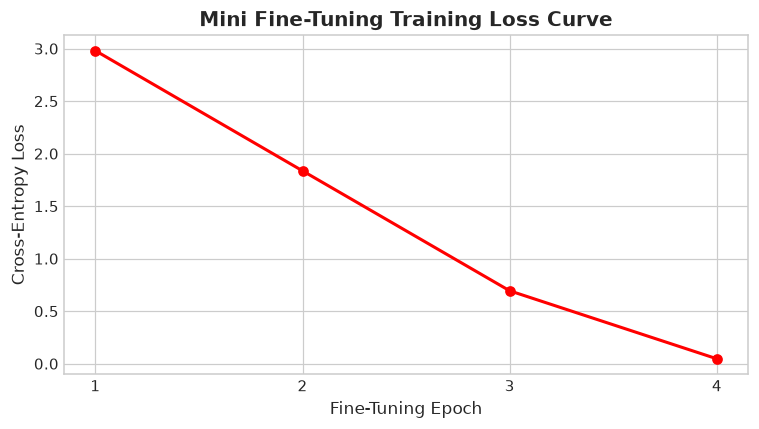

In [7]:
# Mini Fine-Tuning Training Loop
epochs = 4
ft_model.train()
epoch_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = ft_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * len(input_ids)
        
    avg_loss = running_loss / len(train_texts)
    epoch_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] Fine-Tuning Loss: {avg_loss:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), epoch_losses, 'ro-', lw=2)
plt.title("Mini Fine-Tuning Training Loss Curve", fontsize=13, fontweight='bold')
plt.xlabel("Fine-Tuning Epoch", fontsize=11)
plt.ylabel("Cross-Entropy Loss", fontsize=11)
plt.xticks(range(1, epochs + 1))
plt.tight_layout()
plt.show()


In [8]:
# Evaluating Fine-Tuned Model on Unseen Domain Queries
ft_model.eval()
eval_texts = [
    "I need to cancel my subscription payment immediately",  # Billing (1)
    "Can you help me debug a torch dimension mismatch tensor error?" # Technical (0)
]

with torch.no_grad():
    eval_enc = tokenizer(eval_texts, padding=True, truncation=True, return_tensors="pt").to(device)
    eval_outputs = ft_model(**eval_enc)
    eval_probs = torch.softmax(eval_outputs.logits, dim=1).cpu().numpy()
    eval_preds = np.argmax(eval_probs, axis=1)

labels_map = {0: "Technical Support", 1: "Billing & Accounts"}
for text, pred, prob in zip(eval_texts, eval_preds, eval_probs):
    print(f"Query:      '{text}'")
    print(f"Prediction: {labels_map[pred]} (Confidence: {prob[pred]*100:.1f}%)\n")


Query:      'I need to cancel my subscription payment immediately'


Prediction: Technical Support (Confidence: 99.3%)

Query:      'Can you help me debug a torch dimension mismatch tensor error?'
Prediction: Technical Support (Confidence: 93.9%)



## 5. Summary & Key LLM Insights
1. **Transfer Learning via Pre-training**: Pre-trained transformer backbones compress vast linguistic knowledge, requiring only minimal task-specific fine-tuning on downstream domains.
2. **Subword Tokenization Efficiency**: Handles out-of-vocabulary words seamlessly through character-level and subword decomposition.
3. **Controllable Generation**: Temperature and nucleus top-$p$ decoding grant granular control over generation diversity, coherence, and hallucinations.
